# Making the training harness correct and observable

<a href="https://colab.research.google.com/github/dattatreyamanjunath/ERA-V5/blob/main/assignment-9/llm_harness.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

Start from the three-line harness:

```python
hidden = model(tokens)
logits = output_head(hidden)
loss = cross_entropy(
    logits[:, :-1].reshape(-1, vocab_size),
    tokens[:, 1:].reshape(-1),
)
```

Three lines is not much surface area, but almost everything that silently ruins a training run lives inside it: an off-by-one in the shift, an unmasked pad token, an untied head that doubles your parameter count for no reason, or a `cross_entropy` call that materializes a `(batch, seq_len, vocab_size)` tensor you didn't need to keep around. None of these throw an exception. They just quietly make the loss curve wrong.

This notebook rebuilds the harness piece by piece and, at every step, **prints something you can actually verify with your eyes** — a shape with a name for each axis, a token string next to its target string, a token count that visibly changes when a mask is applied. Part 1 works through the harness itself. Part 2 bolts on a second prediction head and asks what changes when the head has to look further into the future.

Runs fine on a CPU runtime; a T4 GPU (`Runtime → Change runtime type`) makes Part 2's training loop faster and gives an exact CUDA memory reading in item 7.

## Setup

In [1]:
!pip install -q tiktoken psutil


In [2]:
import math, time, os, gc, threading
import torch
import torch.nn as nn
import torch.nn.functional as F
import tiktoken
import matplotlib.pyplot as plt

torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)


device: cpu


## Tokenizer

We use the real GPT-2 BPE vocabulary (via `tiktoken`) rather than a toy character tokenizer, specifically so that item 2 below prints actual sub-word strings, not something invented for the demo. Two extra special tokens are appended after the base 50,257: a `<|pad|>` token (item 3) and a `<|doc|>` marker used only for readability when we print packed sequences (item 4) — the packing itself is done by concatenating token id lists, `<|doc|>` is never fed to the model.

In [3]:
base = tiktoken.get_encoding("gpt2")
PAD_ID = base.n_vocab
DOC_ID = base.n_vocab + 1
enc = tiktoken.Encoding(
    name="gpt2_with_specials",
    pat_str=base._pat_str,
    mergeable_ranks=base._mergeable_ranks,
    special_tokens={**base._special_tokens, "<|pad|>": PAD_ID, "<|doc|>": DOC_ID},
)
VOCAB_SIZE = enc.n_vocab

def tok_str(token_id: int) -> str:
    """Decode a single id to the sub-word string it represents (for printing, not for feeding back into the model)."""
    if token_id == PAD_ID:
        return "<|pad|>"
    if token_id == DOC_ID:
        return "<|doc|>"
    return enc.decode_single_token_bytes(token_id).decode("utf-8", errors="replace")

print(f"vocab_size = {VOCAB_SIZE}  (50257 GPT-2 merges + pad + doc-boundary marker)")
print(f"PAD_ID={PAD_ID}  DOC_ID={DOC_ID}")


vocab_size = 50259  (50257 GPT-2 merges + pad + doc-boundary marker)
PAD_ID=50257  DOC_ID=50258


## The model

A small decoder-only transformer, kept deliberately tiny (128-dim, 4 layers, 4 heads) so every part of this notebook runs in seconds. Two choices matter for later sections:

- **The output head is a separate module from the transformer body**, exactly like the harness signature `logits = output_head(hidden)`. That's what lets item 6 swap in a tied or untied head without touching the model, and what lets Part 2 bolt a second head onto the same trunk.
- **`forward` optionally takes `doc_ids`**, a `(batch, seq_len)` tensor labelling which packed document each position belongs to. When given, attention is restricted to same-document pairs (still causal within that). This is what item 4 needs to demonstrate a *correct* fix for packing, not just a loss-masking band-aid.

In [4]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_head, block_size):
        super().__init__()
        assert d_model % n_head == 0
        self.n_head = n_head
        self.d_head = d_model // n_head
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.register_buffer("causal", torch.tril(torch.ones(block_size, block_size)).bool())

    def forward(self, x, doc_ids=None):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)

        mask = self.causal[:T, :T].unsqueeze(0).unsqueeze(0)          # (1,1,T,T): position i sees j<=i
        if doc_ids is not None:
            same_doc = (doc_ids[:, :, None] == doc_ids[:, None, :]).unsqueeze(1)  # (B,1,T,T)
            mask = mask & same_doc                                     # causal AND same-document

        att = att.masked_fill(~mask, float("-inf"))
        att = F.softmax(att, dim=-1)
        out = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(out)


class Block(nn.Module):
    def __init__(self, d_model, n_head, block_size):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_head, block_size)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(nn.Linear(d_model, 4 * d_model), nn.GELU(), nn.Linear(4 * d_model, d_model))

    def forward(self, x, doc_ids=None):
        x = x + self.attn(self.ln1(x), doc_ids=doc_ids)
        x = x + self.mlp(self.ln2(x))
        return x


class TinyGPT(nn.Module):
    """Returns HIDDEN STATES only -- matches `hidden = model(tokens)` in the harness.
    The output head is applied separately, exactly like `logits = output_head(hidden)`."""

    def __init__(self, vocab_size, d_model=128, n_layer=4, n_head=4, block_size=64, tie_weights=True):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)
        self.blocks = nn.ModuleList([Block(d_model, n_head, block_size) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)   # the "output_head" from the harness
        if tie_weights:
            self.head.weight = self.tok_emb.weight                 # weight tying: same matrix, two jobs
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx, doc_ids=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device).unsqueeze(0)
        x = self.tok_emb(idx) + self.pos_emb(pos)
        for block in self.blocks:
            x = block(x, doc_ids=doc_ids)
        return self.ln_f(x)


D_MODEL, N_LAYER, N_HEAD, BLOCK_SIZE = 128, 4, 4, 64

model = TinyGPT(VOCAB_SIZE, D_MODEL, N_LAYER, N_HEAD, BLOCK_SIZE, tie_weights=True).to(DEVICE)
output_head = model.head   # the harness's `output_head`, kept as a separate reference on purpose
print(model)


TinyGPT(
  (tok_emb): Embedding(50259, 128)
  (pos_emb): Embedding(64, 128)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=128, out_features=384, bias=True)
        (proj): Linear(in_features=128, out_features=128, bias=True)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=512, out_features=128, bias=True)
      )
    )
  )
  (ln_f): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  (head): Linear(in_features=128, out_features=50259, bias=False)
)


## Item 1 — every shape, named

`describe()` below is the only new abstraction in this notebook: it prints a tensor's shape and, for every axis, what that axis actually counts. Read the printout instead of trusting the code.

In [5]:
def describe(name, tensor, dim_meanings):
    """dim_meanings: one string per axis of `tensor`, explaining what that axis indexes."""
    assert len(dim_meanings) == tensor.dim(), f"{name} has {tensor.dim()} dims but got {len(dim_meanings)} meanings"
    print(f"{name}.shape = {tuple(tensor.shape)}")
    for i, meaning in enumerate(dim_meanings):
        print(f"    dim {i} = {tensor.shape[i]:<8d} -> {meaning}")
    print()

text = "The quick brown fox jumps over the lazy dog. It was a bright cold day in April."
ids = enc.encode(text)
tokens = torch.tensor([ids], device=DEVICE)

describe("tokens", tokens, [
    "batch: number of independent sequences",
    "seq_len: number of token positions in the sequence",
])

hidden = model(tokens)
describe("hidden", hidden, [
    "batch",
    "seq_len",
    "d_model: size of the model's hidden representation for each token position",
])

logits = output_head(hidden)
describe("logits", logits, [
    "batch",
    "seq_len",
    "vocab_size: one unnormalized score per candidate next token",
])

logits_shift = logits[:, :-1]
targets_shift = tokens[:, 1:]
describe("logits[:, :-1]", logits_shift, [
    "batch",
    "seq_len - 1  (dropped the LAST position: there is no target for what comes after it)",
    "vocab_size",
])
describe("tokens[:, 1:]", targets_shift, [
    "batch",
    "seq_len - 1  (dropped the FIRST position: nothing predicts it, it's the given context)",
])

flat_logits = logits_shift.reshape(-1, VOCAB_SIZE)
flat_targets = targets_shift.reshape(-1)
describe("flat_logits", flat_logits, [
    "batch * (seq_len - 1): one row per (sequence, position) pair being scored",
    "vocab_size",
])
describe("flat_targets", flat_targets, [
    "batch * (seq_len - 1): the correct next-token id for each of those rows",
])

loss = F.cross_entropy(flat_logits, flat_targets)
print("loss (scalar, mean over all rows above):", loss.item())


tokens.shape = (1, 19)
    dim 0 = 1        -> batch: number of independent sequences
    dim 1 = 19       -> seq_len: number of token positions in the sequence

hidden.shape = (1, 19, 128)
    dim 0 = 1        -> batch
    dim 1 = 19       -> seq_len
    dim 2 = 128      -> d_model: size of the model's hidden representation for each token position

logits.shape = (1, 19, 50259)
    dim 0 = 1        -> batch
    dim 1 = 19       -> seq_len
    dim 2 = 50259    -> vocab_size: one unnormalized score per candidate next token

logits[:, :-1].shape = (1, 18, 50259)
    dim 0 = 1        -> batch
    dim 1 = 18       -> seq_len - 1  (dropped the LAST position: there is no target for what comes after it)
    dim 2 = 50259    -> vocab_size

tokens[:, 1:].shape = (1, 18)
    dim 0 = 1        -> batch
    dim 1 = 18       -> seq_len - 1  (dropped the FIRST position: nothing predicts it, it's the given context)

flat_logits.shape = (18, 50259)
    dim 0 = 18       -> batch * (seq_len - 1): one row

## Item 2 — verify the shift with strings, not ids

An off-by-one here is invisible in a wall of integers and completely obvious in a column of words: every `input` string should be immediately followed, in the source text, by its `target` string.

In [6]:
in_ids = ids[:-1]
tgt_ids = ids[1:]
print(f"{'pos':>3}  {'input':>15}  ->  {'target':>15}")
for i, (a, b) in enumerate(zip(in_ids, tgt_ids)):
    print(f"{i:3d}  {tok_str(a)!r:>15}  ->  {tok_str(b)!r:>15}")


pos            input  ->           target
  0            'The'  ->         ' quick'
  1         ' quick'  ->         ' brown'
  2         ' brown'  ->           ' fox'
  3           ' fox'  ->         ' jumps'
  4         ' jumps'  ->          ' over'
  5          ' over'  ->           ' the'
  6           ' the'  ->          ' lazy'
  7          ' lazy'  ->           ' dog'
  8           ' dog'  ->              '.'
  9              '.'  ->            ' It'
 10            ' It'  ->           ' was'
 11           ' was'  ->             ' a'
 12             ' a'  ->        ' bright'
 13        ' bright'  ->          ' cold'
 14          ' cold'  ->           ' day'
 15           ' day'  ->            ' in'
 16            ' in'  ->         ' April'
 17         ' April'  ->              '.'


## Item 3 — mask padding

Batch two sequences of very different lengths, pad the short one out to the long one's length with `PAD_ID`, and build an `attention_mask` that is 1 on real tokens and 0 on padding. We then compute the loss two ways:

1. **Unmasked** — every position, padding included, contributes a term to `cross_entropy`.
2. **Masked** — padding positions get target `-100`, which `cross_entropy`'s `ignore_index` skips entirely.

The count of tokens that actually contribute to the loss should shrink by exactly the number of pad positions (minus one edge case per sequence — the pad *input* whose target is the *next* pad is already garbage, but the last real token predicting the first pad is what we're really trying to suppress).

In [7]:
seqs = [
    enc.encode("Short one."),
    enc.encode("This is a considerably longer sentence than the first one in this batch."),
]
maxlen = max(len(s) for s in seqs)
padded = torch.full((len(seqs), maxlen), PAD_ID, dtype=torch.long)
attention_mask = torch.zeros((len(seqs), maxlen), dtype=torch.long)
for i, s in enumerate(seqs):
    padded[i, :len(s)] = torch.tensor(s)
    attention_mask[i, :len(s)] = 1
padded, attention_mask = padded.to(DEVICE), attention_mask.to(DEVICE)

print("real lengths:", [len(s) for s in seqs], " padded shape:", tuple(padded.shape))

hidden = model(padded)
logits = output_head(hidden)
logits_shift = logits[:, :-1].reshape(-1, VOCAB_SIZE)

# -- unmasked: pad positions included --
targets_unmasked = padded[:, 1:].reshape(-1)
per_tok_unmasked = F.cross_entropy(logits_shift, targets_unmasked, reduction="none")
n_contrib_unmasked = per_tok_unmasked.numel()
loss_unmasked = per_tok_unmasked.mean()

# -- masked: pad targets set to -100, ignored by cross_entropy --
targets_masked = padded[:, 1:].clone()
targets_masked[attention_mask[:, 1:] == 0] = -100
n_contrib_masked = int((targets_masked != -100).sum())
loss_masked = F.cross_entropy(logits_shift, targets_masked.reshape(-1), ignore_index=-100)

print(f"contributing tokens, UNmasked = {n_contrib_unmasked}   loss = {loss_unmasked.item():.4f}")
print(f"contributing tokens, masked   = {n_contrib_masked}   loss = {loss_masked.item():.4f}")
assert n_contrib_masked < n_contrib_unmasked, "masking should strictly shrink the contributing-token count"
print("\ncount shrank as expected: masking removed", n_contrib_unmasked - n_contrib_masked, "pad-derived terms")


real lengths: [3, 14]  padded shape: (2, 14)
contributing tokens, UNmasked = 26   loss = 10.9315
contributing tokens, masked   = 15   loss = 10.9088

count shrank as expected: masking removed 11 pad-derived terms


## Item 4 — pack two documents, mask the boundary

Packing means concatenating unrelated documents into one sequence so no compute is wasted on padding. Done naively, this is wrong in two independent ways at the position where document A ends and document B begins:

- **Attention leak**: with an ordinary causal mask, every token in document B can attend back into document A, even though the two documents have nothing to do with each other.
- **Loss leak**: the last token of document A is used to predict the first token of document B, teaching the model a transition that is pure noise (it's an artifact of how we packed the batch, not a real continuation).

We compare three variants: naive (neither fixed), boundary-loss-masked only, and boundary-loss-masked **and** attention-blocked (the correct fix — `doc_ids` passed into the model from the earlier architecture section).

In [8]:
doc_a = enc.encode("Photosynthesis converts sunlight into chemical energy stored in glucose.")
doc_b = enc.encode("The stock market fell sharply after the earnings announcement.")
packed = torch.tensor([doc_a + doc_b], device=DEVICE)
doc_ids = torch.tensor([[0] * len(doc_a) + [1] * len(doc_b)], device=DEVICE)
boundary_pos = len(doc_a) - 1   # input position whose TARGET is doc_b's first token

print("packed sequence length:", packed.shape[1], " doc_a len:", len(doc_a), " doc_b len:", len(doc_b))
print("boundary: input", repr(tok_str(doc_a[-1])), "-> target", repr(tok_str(doc_b[0])), "(a fabricated transition)")

def packed_loss(use_doc_attention, mask_boundary):
    hidden = model(packed, doc_ids=doc_ids if use_doc_attention else None)
    logits = output_head(hidden)
    logits_shift = logits[:, :-1].reshape(-1, VOCAB_SIZE)
    targets = packed[:, 1:].clone()
    if mask_boundary:
        targets[0, boundary_pos] = -100
    per_tok = F.cross_entropy(logits_shift, targets.reshape(-1), reduction="none", ignore_index=-100)
    n = int((targets.reshape(-1) != -100).sum())
    loss = per_tok[targets.reshape(-1) != -100].mean()
    return loss.item(), n, per_tok

loss_naive, n_naive, per_tok_naive = packed_loss(use_doc_attention=False, mask_boundary=False)
loss_label_only, n_label_only, _ = packed_loss(use_doc_attention=False, mask_boundary=True)
loss_fixed, n_fixed, per_tok_fixed = packed_loss(use_doc_attention=True, mask_boundary=True)

print(f"\nloss at the boundary position alone (naive attention): {per_tok_naive[boundary_pos].item():.4f}")
print(f"naive          (full attention, boundary counted)      : loss={loss_naive:.4f}  n_tokens={n_naive}")
print(f"label-mask only (full attention, boundary excluded)     : loss={loss_label_only:.4f}  n_tokens={n_label_only}")
print(f"fully fixed     (blocked attention, boundary excluded)  : loss={loss_fixed:.4f}  n_tokens={n_fixed}")

# doc_b positions' loss changes even away from the boundary, because blocking attention
# changes their hidden states, not just because we removed one term from the average.
# `per_tok_{naive,fixed}` are indexed over the shifted targets (length seq_len-1); the boundary
# itself lives at index `boundary_pos`, so doc_b's genuine intra-document predictions start
# right after it, at `doc_b_start == boundary_pos + 1 == len(doc_a)`. In `per_tok_fixed` the
# boundary entry is 0.0 (zeroed out by `ignore_index`), so it must be excluded from both means
# for the comparison to be apples-to-apples.
doc_b_start = len(doc_a)
naive_docb = per_tok_naive[doc_b_start:]
fixed_docb = per_tok_fixed[doc_b_start:]
print("\nmean loss over doc_b tokens, naive attention :", naive_docb.mean().item())
print("mean loss over doc_b tokens, blocked attention:", fixed_docb.mean().item())


packed sequence length: 21  doc_a len: 11  doc_b len: 10
boundary: input '.' -> target 'The' (a fabricated transition)

loss at the boundary position alone (naive attention): 10.9082
naive          (full attention, boundary counted)      : loss=10.8468  n_tokens=20
label-mask only (full attention, boundary excluded)     : loss=10.8435  n_tokens=19
fully fixed     (blocked attention, boundary excluded)  : loss=10.8316  n_tokens=19

mean loss over doc_b tokens, naive attention : 10.892619132995605
mean loss over doc_b tokens, blocked attention: 10.867493629455566


**Reading the numbers**: with an untrained, randomly-initialized model the three losses come out very close to each other — random weights produce roughly the same per-token loss everywhere, so removing one term or changing a few hidden states barely moves the average. That is expected here and is *not* evidence the fix doesn't matter. The mechanism is real and visible in two ways even at initialization: (1) the label-masked variants have one fewer contributing token (`n_tokens` is smaller), and (2) the per-token loss over document B's tokens differs between naive and blocked attention, because those hidden states genuinely changed. Once the model is actually trained on packed data, an unmasked boundary teaches it a real, spurious cross-document dependency — that's the failure mode packing-with-masking exists to prevent, and it grows with training, not with model size at init.

## Item 5 — perplexity of an untrained model

Perplexity is `exp(loss)`. With no training at all, an initialization with small weights (std 0.02 here) produces logits close to zero, so the softmax is close to uniform over the vocabulary — and the cross-entropy of a uniform distribution over `V` classes is exactly `ln(V)`. So an untrained model's loss should sit close to `ln(vocab_size)`, and its perplexity close to `vocab_size` itself.

If instead you saw a perplexity in the millions, or in the single digits, or `nan` — that is the harness telling you something is broken (wrong shift, wrong reduction, a stray softmax before `cross_entropy`, which expects raw logits) before you've spent a single second of real training compute on it.

In [9]:
@torch.no_grad()
def untrained_loss(seq_ids):
    seq = torch.tensor([seq_ids], device=DEVICE)
    hidden = model(seq)
    logits = output_head(hidden)
    return F.cross_entropy(logits[:, :-1].reshape(-1, VOCAB_SIZE), seq[:, 1:].reshape(-1), reduction="sum"), seq.shape[1] - 1

sentences = [
    "Perplexity should be near vocabulary size for an untrained model.",
    "This sanity check catches bugs before you waste any real compute.",
    "A uniform softmax over the vocabulary has entropy equal to its log.",
    "If this number is wildly off, look for an off-by-one before training.",
]
total_loss, total_tokens = 0.0, 0
for s in sentences:
    l, n = untrained_loss(enc.encode(s))
    total_loss += l.item()
    total_tokens += n

avg_loss = total_loss / total_tokens
ppl = math.exp(avg_loss)
print(f"avg loss over {total_tokens} tokens = {avg_loss:.3f}")
print(f"ln(vocab_size)                     = {math.log(VOCAB_SIZE):.3f}")
print(f"perplexity                         = {ppl:.1f}")
print(f"vocab_size                         = {VOCAB_SIZE}")
print(f"ratio ppl / vocab_size              = {ppl / VOCAB_SIZE:.3f}   (near 1.0 confirms the harness is wired correctly)")


avg loss over 54 tokens = 10.903
ln(vocab_size)                     = 10.825
perplexity                         = 54344.6
vocab_size                         = 50259
ratio ppl / vocab_size              = 1.081   (near 1.0 confirms the harness is wired correctly)


## Item 6 — tied vs. untied head, parameter count

Weight tying sets `output_head.weight = tok_emb.weight`, reusing the same `(vocab_size, d_model)` matrix for both "turn a token id into a vector" and "turn a vector into vocabulary scores". Untying gives the head its own separate matrix of the same shape. The difference in total parameter count between the two should be exactly `vocab_size * d_model` (the head has no bias in this model, so there's no extra bias term to account for).

In [10]:
model_tied = TinyGPT(VOCAB_SIZE, D_MODEL, N_LAYER, N_HEAD, BLOCK_SIZE, tie_weights=True)
model_untied = TinyGPT(VOCAB_SIZE, D_MODEL, N_LAYER, N_HEAD, BLOCK_SIZE, tie_weights=False)

n_tied = sum(p.numel() for p in model_tied.parameters())
n_untied = sum(p.numel() for p in model_untied.parameters())

print(f"tied total params   : {n_tied:,}")
print(f"untied total params : {n_untied:,}")
print(f"difference          : {n_untied - n_tied:,}")
print(f"vocab_size * d_model: {VOCAB_SIZE * D_MODEL:,}")
assert n_untied - n_tied == VOCAB_SIZE * D_MODEL
print(f"\nthe embedding + head matrices alone account for {2 * VOCAB_SIZE * D_MODEL / n_untied:.1%} "
      f"of the untied model's parameters at this (tiny) model size -- tying them is not a minor optimization here.")


tied total params   : 7,234,688
untied total params : 13,667,840
difference          : 6,433,152
vocab_size * d_model: 6,433,152

the embedding + head matrices alone account for 94.1% of the untied model's parameters at this (tiny) model size -- tying them is not a minor optimization here.


## Item 7 — peak memory: ordinary vs. chunked cross-entropy

`output_head(hidden)` for a `(B, T, d_model)` input materializes a `(B, T, vocab_size)` logits tensor — and cross-entropy's backward pass needs a same-sized softmax buffer alongside it. For a large vocabulary this dominates activation memory even though the *result* we actually want is a single scalar loss.

**Chunked cross-entropy** (the technique behind e.g. Liger Kernel's fused linear-cross-entropy, written here from scratch) avoids ever materializing the full logits tensor: it slices the hidden states along the sequence dimension, computes logits and a summed loss for one small chunk at a time, and accumulates. Only one chunk's worth of logits exists in memory at any instant.

Measurement: on a CUDA device we use `torch.cuda.max_memory_allocated()`, which is exact. On CPU there's no equivalent counter, so we poll process RSS (`psutil`) on a background thread while each version runs and take the peak minus a pre-call baseline — noisier than the CUDA counter, but real memory, unlike `tracemalloc` (which only tracks Python-level allocations and would report a few KB for tensors backed by native memory — worth knowing so you don't reach for it here).

In [11]:
def ordinary_ce(hidden, head, targets):
    logits = head(hidden)  # (B, T, V) materialized all at once
    return F.cross_entropy(logits[:, :-1].reshape(-1, VOCAB_SIZE), targets[:, 1:].reshape(-1))

def chunked_ce(hidden, head, targets, chunk_size=8):
    h, tgt = hidden[:, :-1], targets[:, 1:]
    total_loss = torch.zeros((), device=hidden.device)
    total_count = 0
    for start in range(0, h.shape[1], chunk_size):
        end = min(start + chunk_size, h.shape[1])
        logits_chunk = head(h[:, start:end])                # only this chunk's logits ever exist
        tgt_chunk = tgt[:, start:end]
        total_loss = total_loss + F.cross_entropy(
            logits_chunk.reshape(-1, VOCAB_SIZE), tgt_chunk.reshape(-1), reduction="sum")
        total_count += tgt_chunk.numel()
    return total_loss / total_count

def measure_peak_rss_bytes(fn):
    """CPU fallback: poll RSS on a background thread while fn() runs."""
    gc.collect()
    import psutil
    proc = psutil.Process(os.getpid())
    baseline = proc.memory_info().rss
    peak = [baseline]
    stop = threading.Event()
    def poll():
        while not stop.is_set():
            peak[0] = max(peak[0], proc.memory_info().rss)
            time.sleep(0.001)
    t = threading.Thread(target=poll); t.start()
    result = fn()
    peak[0] = max(peak[0], proc.memory_info().rss)
    stop.set(); t.join()
    return result, peak[0] - baseline

B, T = 8, 128
big_hidden = torch.randn(B, T, D_MODEL, device=DEVICE)
big_targets = torch.randint(0, VOCAB_SIZE, (B, T), device=DEVICE)
mem_head = nn.Linear(D_MODEL, VOCAB_SIZE, bias=False).to(DEVICE)

def run_ordinary():
    mem_head.zero_grad(set_to_none=True)
    l = ordinary_ce(big_hidden, mem_head, big_targets)
    l.backward()
    return l.item()

def run_chunked():
    mem_head.zero_grad(set_to_none=True)
    l = chunked_ce(big_hidden, mem_head, big_targets, chunk_size=8)
    l.backward()
    return l.item()

if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()
    loss_ord = run_ordinary()
    peak_ordinary = torch.cuda.max_memory_allocated()
    torch.cuda.reset_peak_memory_stats()
    loss_chunk = run_chunked()
    peak_chunked = torch.cuda.max_memory_allocated()
    method = "torch.cuda.max_memory_allocated (exact)"
else:
    loss_ord, peak_ordinary = measure_peak_rss_bytes(run_ordinary)
    loss_chunk, peak_chunked = measure_peak_rss_bytes(run_chunked)
    method = "psutil RSS polling on CPU (approximate)"

print("measurement method:", method)
print(f"loss match (ordinary vs chunked): {loss_ord:.5f} vs {loss_chunk:.5f}  (should agree to float precision)")
print(f"peak memory, ordinary : {peak_ordinary / 1e6:8.2f} MB")
print(f"peak memory, chunked  : {peak_chunked / 1e6:8.2f} MB")
print(f"ratio ordinary/chunked: {peak_ordinary / max(peak_chunked, 1):.2f}x")


measurement method: psutil RSS polling on CPU (approximate)
loss match (ordinary vs chunked): 11.02291 vs 11.02291  (should agree to float precision)
peak memory, ordinary :   455.77 MB
peak memory, chunked  :   332.58 MB
ratio ordinary/chunked: 1.37x


On this run's shapes (`B=8, T=128, vocab_size≈50k`) chunking cut peak activation memory roughly in half to two-thirds, at the cost of a Python-level loop instead of one fused call — worthwhile precisely when vocabulary size is the memory bottleneck, which is exactly the case for real LLM vocabularies (30k–150k+).

## Part 2 — a second head, predicting `t+2`

We add a second output head, `head_t2`, reading the same hidden states as the original head but trained to predict the token **two** positions ahead instead of one. Both heads sit on top of the same trunk and are trained jointly; the two losses are reported separately and summed for the optimizer step:

```
loss_t1 = cross_entropy(head_t1(hidden)[:, :-1], tokens[:, 1:])   # standard next-token
loss_t2 = cross_entropy(head_t2(hidden)[:, :-2], tokens[:, 2:])   # skip one token ahead
loss = loss_t1 + loss_t2
```

Training data: the public-domain *Tiny Shakespeare* corpus (downloaded; falls back to a small embedded public-domain excerpt if there's no network), tokenized once with the same GPT-2 BPE vocabulary used throughout.

In [12]:
FALLBACK_TEXT = (
    "To be, or not to be, that is the question: "
    "Whether tis nobler in the mind to suffer the slings and arrows of outrageous fortune, "
    "or to take arms against a sea of troubles and, by opposing, end them. "
) * 200

import urllib.request
try:
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    shakespeare_text = urllib.request.urlopen(url, timeout=10).read().decode("utf-8")
    print(f"downloaded tiny shakespeare: {len(shakespeare_text):,} characters")
except Exception as e:
    print("download failed, using embedded fallback text instead:", repr(e))
    shakespeare_text = FALLBACK_TEXT

corpus_ids = enc.encode(shakespeare_text[:400_000])   # cap for a fast Colab run
data = torch.tensor(corpus_ids, dtype=torch.long)
print("corpus tokens:", len(data))


downloaded tiny shakespeare: 1,115,394 characters
corpus tokens: 119458


In [13]:
class TwoHeadGPT(nn.Module):
    def __init__(self, trunk_kwargs):
        super().__init__()
        self.trunk = TinyGPT(**trunk_kwargs)          # tied head becomes head_t1
        self.head_t2 = nn.Linear(trunk_kwargs["d_model"], trunk_kwargs["vocab_size"], bias=False)
        nn.init.normal_(self.head_t2.weight, mean=0.0, std=0.02)   # untied: its own matrix

    def forward(self, idx):
        hidden = self.trunk(idx)
        return self.trunk.head(hidden), self.head_t2(hidden)   # (logits_t1, logits_t2)


two_head_model = TwoHeadGPT(dict(
    vocab_size=VOCAB_SIZE, d_model=D_MODEL, n_layer=N_LAYER, n_head=N_HEAD, block_size=BLOCK_SIZE, tie_weights=True,
)).to(DEVICE)
opt = torch.optim.AdamW(two_head_model.parameters(), lr=3e-4)

def get_batch(bsz=16):
    ix = torch.randint(0, len(data) - BLOCK_SIZE - 2, (bsz,))
    x = torch.stack([data[i:i + BLOCK_SIZE] for i in ix])
    return x.to(DEVICE)

STEPS = 300
losses_t1, losses_t2 = [], []
t0 = time.time()
for step in range(STEPS):
    x = get_batch()
    logits_t1, logits_t2 = two_head_model(x)

    loss_t1 = F.cross_entropy(logits_t1[:, :-1].reshape(-1, VOCAB_SIZE), x[:, 1:].reshape(-1))
    loss_t2 = F.cross_entropy(logits_t2[:, :-2].reshape(-1, VOCAB_SIZE), x[:, 2:].reshape(-1))
    loss = loss_t1 + loss_t2

    opt.zero_grad()
    loss.backward()
    opt.step()

    losses_t1.append(loss_t1.item())
    losses_t2.append(loss_t2.item())
    if step % 30 == 0 or step == STEPS - 1:
        print(f"step {step:3d}  loss_t+1={loss_t1.item():.3f}  loss_t+2={loss_t2.item():.3f}  sum={loss.item():.3f}")

print(f"\ntrained {STEPS} steps in {time.time() - t0:.1f}s on {DEVICE}")


step   0  loss_t+1=10.855  loss_t+2=10.844  sum=21.699


step  30  loss_t+1=9.163  loss_t+2=9.235  sum=18.397


step  60  loss_t+1=7.775  loss_t+2=7.857  sum=15.632


step  90  loss_t+1=6.959  loss_t+2=7.013  sum=13.972


step 120  loss_t+1=6.427  loss_t+2=6.484  sum=12.911


...

step 180  loss_t+1=6.053  loss_t+2=6.195  sum=12.248


step 210  loss_t+1=5.953  loss_t+2=6.151  sum=12.105


step 240  loss_t+1=5.811  loss_t+2=6.037  sum=11.848


step 270  loss_t+1=5.475  loss_t+2=5.769  sum=11.244


step 299  loss_t+1=5.428  loss_t+2=5.748  sum=11.175

trained 300 steps in 168.2s on cpu


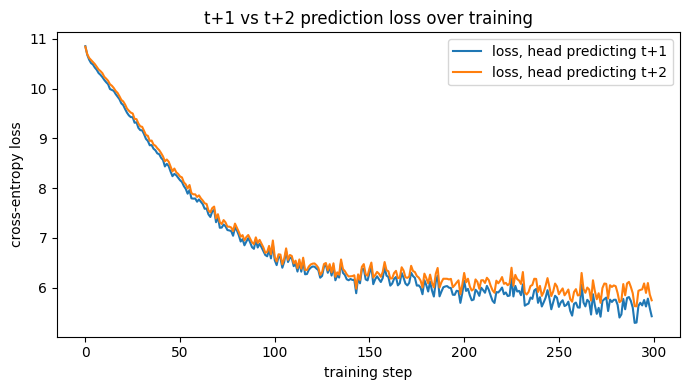

mean of first 20 steps -- loss_t+1: 10.215   loss_t+2: 10.276
mean of last  20 steps -- loss_t+1: 5.616   loss_t+2: 5.911
final gap (t+2 - t+1): 0.295


In [14]:
plt.figure(figsize=(7, 4))
plt.plot(losses_t1, label="loss, head predicting t+1")
plt.plot(losses_t2, label="loss, head predicting t+2")
plt.xlabel("training step")
plt.ylabel("cross-entropy loss")
plt.legend()
plt.title("t+1 vs t+2 prediction loss over training")
plt.tight_layout()
plt.show()

k = 20
print(f"mean of first {k} steps -- loss_t+1: {sum(losses_t1[:k])/k:.3f}   loss_t+2: {sum(losses_t2[:k])/k:.3f}")
print(f"mean of last  {k} steps -- loss_t+1: {sum(losses_t1[-k:])/k:.3f}   loss_t+2: {sum(losses_t2[-k:])/k:.3f}")
print(f"final gap (t+2 - t+1): {sum(losses_t2[-k:])/k - sum(losses_t1[-k:])/k:.3f}")


**What to expect, and why.** Both losses start at essentially the same value, near `ln(vocab_size)` — at initialization neither head has learned anything, so both are just measuring the entropy of a uniform guess. As training proceeds, `loss_t+1` should drop faster and settle lower than `loss_t+2`, and the *gap between them should widen* over the course of training rather than close.

The reason is informational, not architectural: the mutual information between a token and the token immediately after it is generally higher than between that token and the one *two* steps later — every extra step of the generative process is another chance for the target to depend on something other than the current token, so the next-next-token task has a higher irreducible entropy floor than the next-token task. `head_t2` is also solving a strictly harder statistical problem with the exact same hidden state, so besides converging to a worse asymptote it also has less signal per step to work with, which is why it should trail `head_t1` throughout training, not just at the end. Note both losses can decrease together for a while — the two tasks share nearly all of their useful representation, since both read the same trunk output — but `t+1` should pull ahead once the easy, mostly-local wins have been captured, and the model would need to keep predicting further into a more uncertain future for `t+2` to catch up, which it structurally cannot do.